In [16]:
import numpy as np
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm
import matplotlib.pyplot as plt
from utils import simulate_bagging_and_ijk_var_calculation

Simulations: 100%|██████████| 1000/1000 [00:01<00:00, 843.15simulation/s]



Mean of IJK_var_est of bagged_mean_estimator: 0.0395990953
True variance of bagged_mean_estimator: 0.04

0.03879110255492356


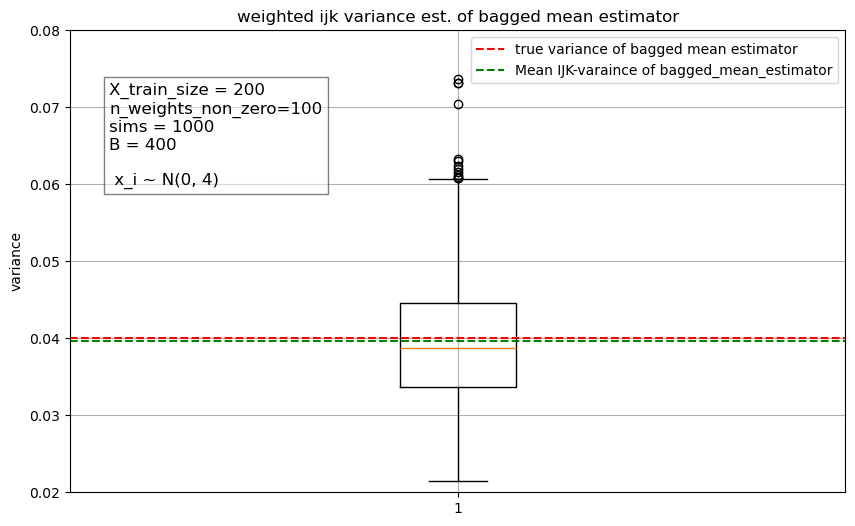

In [17]:
####### Simulation parameters  #########
n_x = 2_00
n_sim = 1000
B = 400
portion_non_zero_weights = 0.5
var_x =4
seed = 41

# run simulation
with ProcessPoolExecutor() as executor:
    
    m = int(n_x * portion_non_zero_weights)
    rng = np.random.default_rng(seed)
    x_sim = rng.normal(0, var_x**0.5, (n_sim, n_x))
    weights = np.zeros(n_x)
    weights[:m] = 1 / m

    theta_bagged = np.zeros(n_sim)
    theta_bagged_var_ijk = np.zeros(n_sim)

    futures = [
        executor.submit(
            simulate_bagging_and_ijk_var_calculation,
            x1=x_sim[i],
            B=B,
            sim_i=i,
            seed=seed,
            weights=weights,
            m=m,
        )
        for i in range(n_sim)
    ]

    for i, future in enumerate(tqdm(futures, desc="Simulations", unit="simulation")):
        _theta_bagged_var_ijk, _theta_bagged = future.result()
        theta_bagged[i] = _theta_bagged
        theta_bagged_var_ijk[i] = _theta_bagged_var_ijk
        
    true_var =  var_x / m
    print(f"\nMean of IJK_var_est of bagged_mean_estimator: {round(theta_bagged_var_ijk.mean(),10)}")
    print(f"True variance of bagged_mean_estimator: {true_var}\n")
    
def plot():
    print(np.quantile(theta_bagged_var_ijk, 0.5))
    plt.figure(figsize=(10, 6))
    plt.boxplot(theta_bagged_var_ijk, )
    plt.grid(True)
    plt.axhline(y=true_var, color='r', linestyle='--', label='true variance of bagged mean estimator')
    plt.axhline(y=round(theta_bagged_var_ijk.mean(),10), color='g', linestyle='--', label='Mean IJK-varaince of bagged_mean_estimator')
    plt.text(
        0.55,
        0.06,
        f"X_train_size = {n_x}\nn_weights_non_zero={m}\nsims = {n_sim}\nB = {B}\n\n x_i ~ N(0, {var_x})",
        fontsize=12,
        bbox=dict(facecolor="white", alpha=0.5),
    ) 
    plt.ylim(0.02, 0.08)
    plt.legend()
    plt.title('weighted ijk variance est. of bagged mean estimator')
    plt.ylabel('variance')
    plt.savefig('var_ijk_weighted_bagged_mean_est.png')

    np.quantile(theta_bagged_var_ijk, 0.5)
    
plot()

Simulations: 100%|██████████| 1000/1000 [00:01<00:00, 996.27simulation/s]



Mean of IJK_var_est of bagged_mean_estimator: 0.039493017
True variance of bagged_mean_estimator: 0.04

0.03858522967518456


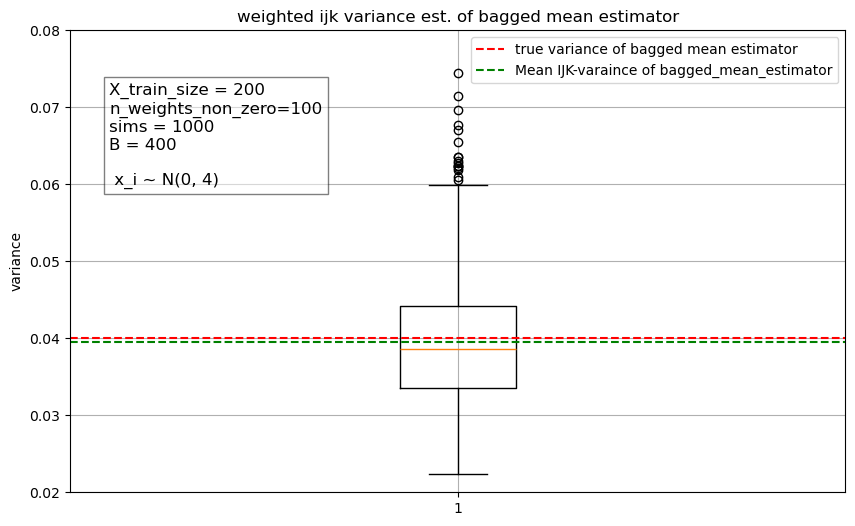

In [18]:

# run simulation
with ProcessPoolExecutor() as executor:
    
    m = int(n_x * portion_non_zero_weights)
    rng = np.random.default_rng(seed)
    x_sim = rng.normal(0, var_x**0.5, (n_sim, n_x))
    weights = np.zeros(n_x)
    weights[:m] = 1 / m
    
    # reduce dataset size to points with non-zero weights
    weights = weights[:m]

    x_sim = x_sim[:, :m]

    theta_bagged = np.zeros(n_sim)
    theta_bagged_var_ijk = np.zeros(n_sim)

    futures = [
        executor.submit(
            simulate_bagging_and_ijk_var_calculation,
            x1=x_sim[i],
            B=B,
            sim_i=i,
            seed=seed,
            weights=weights,
            m=m,
        )
        for i in range(n_sim)
    ]

    for i, future in enumerate(tqdm(futures, desc="Simulations", unit="simulation")):
        _theta_bagged_var_ijk, _theta_bagged = future.result()
        theta_bagged[i] = _theta_bagged
        theta_bagged_var_ijk[i] = _theta_bagged_var_ijk
        
    true_var =  var_x / m
    print(f"\nMean of IJK_var_est of bagged_mean_estimator: {round(theta_bagged_var_ijk.mean(),10)}")
    print(f"True variance of bagged_mean_estimator: {true_var}\n")
    
def plot():
    print(np.quantile(theta_bagged_var_ijk, 0.5))
    plt.figure(figsize=(10, 6))
    plt.boxplot(theta_bagged_var_ijk, )
    plt.grid(True)
    plt.axhline(y=true_var, color='r', linestyle='--', label='true variance of bagged mean estimator')
    plt.axhline(y=round(theta_bagged_var_ijk.mean(),10), color='g', linestyle='--', label='Mean IJK-varaince of bagged_mean_estimator')
    plt.text(
        0.55,
        0.06,
        f"X_train_size = {n_x}\nn_weights_non_zero={m}\nsims = {n_sim}\nB = {B}\n\n x_i ~ N(0, {var_x})",
        fontsize=12,
        bbox=dict(facecolor="white", alpha=0.5),
    ) 
    plt.ylim(0.02, 0.08)
    plt.legend()
    plt.title('weighted ijk variance est. of bagged mean estimator')
    plt.ylabel('variance')
    plt.savefig('var_ijk_weighted_bagged_mean_est.png')

    np.quantile(theta_bagged_var_ijk, 0.5)
    
plot()